<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB44·P6 · Puente de Python (6): NumPy intermedio para robótica

**Puente de Python — Lección 6 de 7**

> En el NB15 y el NB27 aprendiste NumPy: arrays, `shape`, operaciones elemento a elemento, `@`, ejes, broadcasting, máscaras, vistas. En el Bloque A (NB45-NB50) lo vas a necesitar a fondo: jacobianos de 3×9, matrices de rotación, `np.linalg.pinv`, `svd`, lotes de estados de forma (8, 10.000, 19)... y la trampa de las vistas de MuJoCo. Hoy hacemos el puente: el NumPy que de verdad se usa en robótica, con datos de Zancudo.

La habilidad que vamos a entrenar tiene nombre: **pensar en formas**. Un programador de NumPy con experiencia, antes de escribir una operación, se pregunta: "¿qué forma tiene cada array, y qué forma tendrá el resultado?". Si contestas eso, el resto sale solo, y los errores de forma (los más comunes, P1) desaparecen.


In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"
import time
import numpy as np
import mujoco
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True, linewidth=120)

zancudo = mujoco.MjModel.from_xml_path("robots/zancudo.xml")

## 1 · Pensar en formas

### Las formas típicas de la robótica

Casi todo lo que manejarás encaja en unas pocas formas. Apréndelas como un vocabulario:

| Forma | Qué es | Ejemplo |
|---|---|---|
| `(n,)` | un **vector**: un estado, una acción | `qpos` de Zancudo: `(9,)` |
| `(T, n)` | una **trayectoria**: T instantes, n números en cada uno | 1.000 pasos de `qpos`: `(1000, 9)` |
| `(N, 3)` | una **nube de puntos**: N puntos en 3D | las posiciones de los 8 cuerpos: `(8, 3)` |
| `(3, 3)` | una **matriz de rotación** (NB46) | la orientación del torso |
| `(3, nv)` | un **jacobiano** (NB46: cuánto se mueve el pie al mover cada articulación) | el del pie: `(3, 9)` |
| `(N, 3, 3)` | un **lote** de N rotaciones | la orientación de cada cuerpo: `(8, 3, 3)` |
| `(E, T, n)` | E trayectorias (episodios, semillas...) | el `rollout` que verás en el NB49: `(8, 10000, 19)` |

La convención casi universal: **el tiempo (o el índice del lote) va primero**, y las coordenadas, al final. Así, `trayectoria[t]` es el estado en el instante t, y `trayectoria[:, j]` es la evolución de la coordenada j a lo largo del tiempo.

MuJoCo sigue la misma lógica: `datos.xpos` (posiciones de los cuerpos) es `(nbody, 3)`, `datos.xmat` (sus rotaciones) es `(nbody, 9)` (cada matriz de 3×3 **aplanada** en 9 números, por cómo la guarda C):


In [2]:
d = mujoco.MjData(zancudo)
mujoco.mj_forward(zancudo, d)
print("qpos:", d.qpos.shape, "| xpos:", d.xpos.shape, "| xmat:", d.xmat.shape)
rotaciones = d.xmat.reshape(-1, 3, 3)           # de (8, 9) a (8, 3, 3): 8 matrices de 3×3
print("rotaciones:", rotaciones.shape)
print("la del torso (cuerpo 1):\n", rotaciones[1])

qpos: (9,) | xpos: (8, 3) | xmat: (8, 9)
rotaciones: (8, 3, 3)
la del torso (cuerpo 1):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


`reshape(-1, 3, 3)` (NB27): "reorganiza en bloques de 3×3; el `-1` significa 'calcula tú cuántos'". 72 números / 9 = 8 matrices. La del torso es la identidad: está derecho.

## 2 · Grabar una trayectoria

### Reservar frente a añadir

Para tener datos interesantes, simulemos 3 segundos de Zancudo con una orden de agacharse al segundo 1 y de estirarse al segundo 2, y grabemos `qpos` en cada paso. Hay dos formas de grabar:

1. **Añadir a una lista** y convertir al final: `lista.append(d.qpos.copy())` y luego `np.array(lista)`. Sencillo y flexible (no hace falta saber cuántos pasos habrá).
2. **Reservar** el array entero de antemano con `np.empty((T, n))` (o `np.zeros`) y **rellenar** cada fila. Un poco más rápido y sin memoria duplicada; requiere saber T.


In [3]:
T = 1500                                         # 3 s a 0,002 s por paso
agachado = np.array([0.5, -1.0, 0.5] * 2)

def ordenes(t: float) -> np.ndarray:
    return agachado if 1.0 <= t < 2.0 else np.zeros(6)

d = mujoco.MjData(zancudo)
tray = np.empty((T, zancudo.nq))                 # reservado: (1500, 9), con basura dentro
tiempos = np.empty(T)
contactos = np.empty(T, dtype=int)
for paso in range(T):
    d.ctrl[:] = ordenes(d.time)
    mujoco.mj_step(zancudo, d)
    tray[paso] = d.qpos                          # copia los 9 números EN la fila (no guarda una vista)
    tiempos[paso] = d.time
    contactos[paso] = d.ncon

print("trayectoria:", tray.shape, tray.dtype, "| contactos:", contactos.shape, contactos.dtype)

trayectoria: (1500, 9) float64 | contactos: (1500,) int64


Dos detalles importantes:

- **`np.empty`** reserva memoria **sin inicializarla**: lo que hay dentro es "basura" (lo que hubiera antes en esa memoria). Es un poco más rápido que `np.zeros`, pero si te olvidas de rellenar alguna fila, tendrás números absurdos sin aviso. Úsalo solo si vas a rellenarlo **entero**.
- **`tray[paso] = d.qpos`** **copia** los valores dentro de la fila del array (la asignación a una porción escribe **dentro**, NB27). No hay trampa de vistas aquí, a diferencia de `lista.append(d.qpos)` sin `.copy()`, que guardaría 1.500 veces la misma vista (P1).

### Porciones: columnas y filas

Con la trayectoria como array, todo se reduce a **porciones**:


(1500,) (1500, 2) (1500, 3) (15, 9) (501, 9)


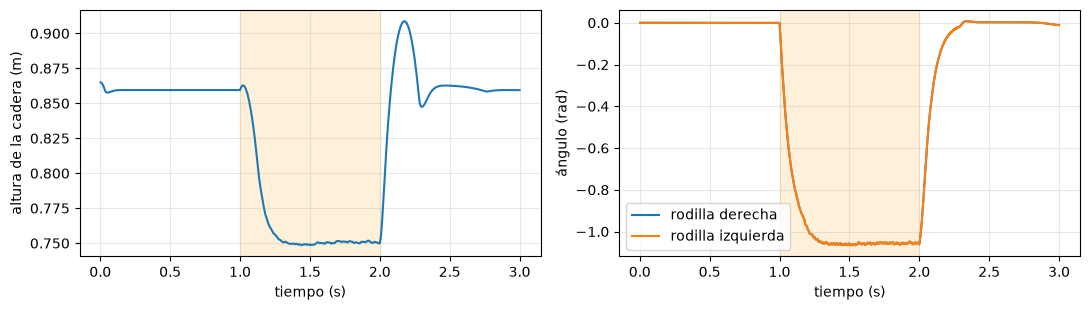

In [4]:
altura = 0.865 + tray[:, 1]                       # columna 1 (raiz_z), TODOS los instantes: (1500,)
rodillas = tray[:, [4, 7]]                        # las dos rodillas: (1500, 2)
pierna_d = tray[:, 3:6]                           # cadera, rodilla y tobillo derechos: (1500, 3)
cada_100 = tray[::100]                            # una de cada 100 filas: (15, 9)
ultimo_segundo = tray[tiempos >= 2.0]             # las filas del último segundo (máscara, sección 3)
print(altura.shape, rodillas.shape, pierna_d.shape, cada_100.shape, ultimo_segundo.shape)

fig, ejes = plt.subplots(1, 2, figsize=(11, 3.2))
ejes[0].plot(tiempos, altura)
ejes[0].set(xlabel="tiempo (s)", ylabel="altura de la cadera (m)")
ejes[1].plot(tiempos, rodillas, label=["rodilla derecha", "rodilla izquierda"])
ejes[1].set(xlabel="tiempo (s)", ylabel="ángulo (rad)")
ejes[1].legend()
for eje in ejes:
    eje.axvspan(1, 2, color="orange", alpha=0.15)
    eje.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Lee bien cada porción, porque este es el pan de cada día:

- **`tray[:, 1]`**: "todas las filas, columna 1". El `:` es "todo" en esa dimensión. El resultado es **un vector** de 1.500 números (la dimensión de la columna desaparece al pedir **un** número).
- **`tray[:, [4, 7]]`**: con una **lista** de columnas, se queda con esas dos: `(1500, 2)`. (Las rodillas son las coordenadas 4 y 7: `raiz_x, raiz_z, raiz_giro, cadera_d, rodilla_d, tobillo_d, cadera_i, rodilla_i, tobillo_i`.)
- **`tray[:, 3:6]`**: de la columna 3 a la 5: `(1500, 3)`.
- **`tray[::100]`**: filas de 100 en 100 (la segunda dimensión, sin escribir, es "todo").
- `plt.plot(tiempos, rodillas)` con una matriz de 2 columnas dibuja **una línea por columna**, y `label` acepta una lista.

En la gráfica se ve el agachado (zona naranja): la cadera baja de 0,86 a 0,75 m y las rodillas se doblan hasta −1,05 rad; al estirarse, vuelve.


## 3 · Máscaras e índices avanzados

### Preguntas de sí o no, para todos a la vez

Una **máscara** es un array de booleanos con la misma forma que los datos (NB27): `True` donde se cumple una condición. Con ella se **filtra** (`datos[mascara]`), se **cuenta** (`mascara.sum()`, porque `True` vale 1) y se **localiza**:


In [5]:
agachado_de_verdad = altura < 0.8                 # (1500,) de True/False
print("pasos con la cadera por debajo de 0,8 m:", agachado_de_verdad.sum(),
      f"= {agachado_de_verdad.sum() * 0.002:.2f} s")
print("¿alguna vez sin contactos?", (contactos == 0).any(), "| ¿siempre?", (contactos == 0).all())

indices = np.flatnonzero(agachado_de_verdad)      # las POSICIONES de los True
print("primer y último paso agachado:", indices[0], indices[-1],
      f"→ de {tiempos[indices[0]]:.3f} s a {tiempos[indices[-1]]:.3f} s")

pasos con la cadera por debajo de 0,8 m: 453 = 0.91 s
¿alguna vez sin contactos? True | ¿siempre? False
primer y último paso agachado: 565 1017 → de 1.132 s a 2.036 s


- **`mascara.sum()`**: cuántos `True`. Multiplicado por el pasito, **cuánto tiempo** pasa algo.
- **`.any()`** / **`.all()`**: ¿alguno? / ¿todos? (los equivalentes de `any`/`all` de Python, NB21, pero vectorizados).
- **`np.flatnonzero(mascara)`**: las **posiciones** de los `True` (el mismo resultado que `np.where(mascara)[0]`, NB27, sin la tupla).

Combinar condiciones se hace con **`&`** (y), **`|`** (o) y **`~`** (no), **con paréntesis** alrededor de cada comparación, porque estos operadores tienen más prioridad que `<` o `==`:


In [6]:
en_la_fase_de_agachado = (tiempos >= 1.0) & (tiempos < 2.0)
bajo_pero_fuera_de_fase = agachado_de_verdad & ~en_la_fase_de_agachado
print("pasos bajos fuera de la fase de agachado:", bajo_pero_fuera_de_fase.sum())
print("primer instante:", tiempos[bajo_pero_fuera_de_fase][0] if bajo_pero_fuera_de_fase.any() else None)

pasos bajos fuera de la fase de agachado: 19
primer instante: 2.0000000000000013


Hay pasos con la cadera baja **después** de que termine la fase de agachado: es lo que tarda en estirarse (la cadera no sube de golpe a los 2,0 s, sino que tarda unas décimas: los motores son muelles con amortiguador, NB40).

(Y la trampa clásica: escribir `tiempos >= 1.0 & tiempos < 2.0` **sin** paréntesis da un error extraño, porque Python calcula primero `1.0 & tiempos`. Y escribir `and` en vez de `&` da el `ValueError: The truth value of an array... is ambiguous` del P3: `and` solo sabe trabajar con **un** booleano, no con arrays.)

### El primer instante en que algo pasa

Un modismo muy útil: **`np.argmax(mascara)`** da la posición del **primer** `True` (porque `argmax` devuelve el primer máximo, y `True` > `False`). Lo usarás en el NB49 y el NB50 para medir "cuándo llega al 90 %". Pero cuidado con su trampa:


In [7]:
print("primer paso bajo 0,8 m:", np.argmax(altura < 0.8))
print("primer paso bajo 0,1 m:", np.argmax(altura < 0.1), "← ¡ojo! nunca baja de 0,1 m...")
print("comprobación:", (altura < 0.1).any())

primer paso bajo 0,8 m: 565
primer paso bajo 0,1 m: 0 ← ¡ojo! nunca baja de 0,1 m...
comprobación: False


Si **ningún** elemento es `True`, `argmax` devuelve **0** (el primer máximo de un array todo `False`), que parece "ocurrió en el paso 0". Siempre hay que comprobar con `.any()` antes, o usar `np.flatnonzero` (que daría un array vacío).

### Índices con listas: siempre copias

Un último detalle, que conecta con las vistas (sección 7). Las **porciones** (`a[2:5]`, `a[:, 3]`) dan **vistas**; pero los **índices con listas o con máscaras** (`a[[4, 7]]`, `a[mascara]`) dan **copias**. Así que modificar el resultado no toca el original... y asignar **a través de** ellos sí que escribe en el original:


In [8]:
a = np.arange(6.0)
seleccion = a[[1, 3]]          # copia
seleccion[:] = 99
print(a)                       # sin cambios
a[[1, 3]] = 99                 # asignación DIRECTA con índices: escribe en a
print(a)
a[a > 50] = 0                  # el modismo de "recortar" con una máscara
print(a)

[0. 1. 2. 3. 4. 5.]
[ 0. 99.  2. 99.  4.  5.]
[0. 0. 2. 0. 4. 5.]


## 4 · Reducciones por ejes y diferencias

### axis: a lo largo de qué dimensión

Las **reducciones** (`sum`, `mean`, `max`, `min`, `std`, `argmax`...) aceptan **`axis`** (NB27): la dimensión que se **colapsa**. La forma de pensarlo: `axis=0` recorre las **filas** (el tiempo) y deja una respuesta **por columna**; `axis=1` recorre las columnas y deja una respuesta **por fila**:


In [9]:
articulaciones = tray[:, 3:]                                 # (1500, 6)
print("media de cada articulación en el tiempo (axis=0):", articulaciones.mean(axis=0).round(3), articulaciones.mean(axis=0).shape)
print("ángulo máximo (en valor absoluto) de cada una:    ", np.abs(articulaciones).max(axis=0).round(3))
print("suma de los 6 ángulos en cada instante (axis=1):  ", articulaciones.sum(axis=1).shape)
print("¿en qué paso alcanza cada una su mínimo?          ", articulaciones.argmin(axis=0))

media de cada articulación en el tiempo (axis=0): [ 0.167 -0.354  0.177  0.167 -0.354  0.177] (6,)
ángulo máximo (en valor absoluto) de cada una:     [0.5   1.066 0.507 0.5   1.066 0.507]
suma de los 6 ángulos en cada instante (axis=1):   (1500,)
¿en qué paso alcanza cada una su mínimo?           [1499  760 1499 1499  760 1499]


Una regla mnemotécnica infalible: **la forma del resultado es la forma del original sin la dimensión del `axis`**. `(1500, 6)` con `axis=0` → `(6,)`; con `axis=1` → `(1500,)`. Y con `keepdims=True`, la dimensión se queda con tamaño 1: `(1, 6)`, útil para el broadcasting (sección 5).

### Diferencias: velocidades desde posiciones

En el P4 calculamos velocidades con `itertools.pairwise`, de dos en dos. En NumPy, **`np.diff`** hace lo mismo para todo el array a la vez: `np.diff(x)` = `[x[1] − x[0], x[2] − x[1], ...]` (un elemento **menos**):


In [10]:
velocidad_cadera = np.diff(altura) / np.diff(tiempos)                # (1499,): ¡uno menos!
velocidad_central = np.gradient(altura, tiempos)                       # (1500,): misma longitud
print(velocidad_cadera.shape, velocidad_central.shape)
print(f"velocidad máxima de bajada: {velocidad_cadera.min():.3f} m/s;  de subida: {velocidad_cadera.max():.3f} m/s")

# comparación con la velocidad que calcula MuJoCo, al final de la simulación
print(f"último paso: diferencias {velocidad_cadera[-1]:.5f} | MuJoCo {d.qvel[1]:.5f}")

(1499,) (1500,)
velocidad máxima de bajada: -1.065 m/s;  de subida: 1.797 m/s
último paso: diferencias 0.00206 | MuJoCo 0.00206


- **`np.diff`** da la diferencia entre vecinos: con `/ np.diff(tiempos)`, una velocidad (NB16: pendiente = cambio / tiempo). Tiene un elemento menos, así que para dibujarla contra el tiempo hay que usar `tiempos[1:]`.
- **`np.gradient(x, t)`** calcula la pendiente en **cada** punto (con diferencias "centradas" en el interior: la media de la de antes y la de después), y conserva la longitud. Más cómoda para dibujar.
- La diferencia de posiciones coincide (casi) con la velocidad que integra MuJoCo: con el integrador semiimplícito (NB39b; lo verás a fondo en el NB49), la posición nueva se calcula **con** la velocidad nueva, así que `(q_nuevo − q_viejo) / dt` es justo esa velocidad.

Y la operación inversa, **`np.cumsum`** (suma acumulada), reconstruye una posición sumando velocidades × dt: es una integral "a mano" (NB16), lo mismo que `itertools.accumulate` del P4, pero vectorizada.


## 5 · Broadcasting a fondo

### Las tres reglas

En el NB27 viste que NumPy sabe operar arrays de **formas distintas**, "estirando" los pequeños. Se llama **broadcasting** (difusión). Ahora, las **reglas exactas**, que son solo tres. Para operar dos arrays, NumPy compara sus formas **empezando por la derecha**:

1. Si un array tiene **menos** dimensiones, se le añaden dimensiones de tamaño 1 **por la izquierda**: `(3,)` se trata como `(1, 3)`.
2. Dos dimensiones son compatibles si son **iguales**, o si **una de ellas es 1** (que se "estira" hasta la otra).
3. Si alguna pareja no cumple la regla 2, error: `operands could not be broadcast together` (P1).

Ejemplos:

```
   (1500, 6)  -  (6,)      →  (1500, 6)  -  (1, 6)   →  (1500, 6)     ✓  restar a cada fila un vector
   (1500, 6)  -  (1500,)   →  (1500, 6)  -  (1, 1500) →  ¡6 ≠ 1500!   ✗  error
   (1500, 6)  -  (1500, 1) →                             (1500, 6)     ✓  restar a cada columna un vector
   (8, 1, 3)  -  (1, 5, 3) →                             (8, 5, 3)     ✓  ¡todas las parejas!
```

El segundo caso es **el** error típico: quieres restar a cada fila su media (`(1500,)`), y NumPy intenta alinearla con las **columnas**. Arreglo: darle forma de columna, `(1500, 1)`, con `keepdims=True` o con `[:, None]`:


In [11]:
media_por_instante = articulaciones.mean(axis=1)                        # (1500,)
centradas = articulaciones - media_por_instante[:, None]                 # (1500, 6) - (1500, 1)
centradas_2 = articulaciones - articulaciones.mean(axis=1, keepdims=True)
print(centradas.shape, np.allclose(centradas, centradas_2))

# normalizar cada columna (media 0, desviación 1): lo que hace un "normalizador de observaciones" (NB27)
normalizadas = (articulaciones - articulaciones.mean(axis=0)) / (articulaciones.std(axis=0) + 1e-8)
print(normalizadas.mean(axis=0).round(6), normalizadas.std(axis=0).round(3))

(1500, 6) True
[-0. -0.  0.  0.  0. -0.] [1. 1. 1. 1. 1. 1.]


**`[:, None]`** añade una dimensión de tamaño 1 en esa posición (`None` es un alias de `np.newaxis`): de `(1500,)` a `(1500, 1)`. Es el truco más usado para preparar un broadcasting. (Y el `+ 1e-8` evita dividir por cero si alguna columna fuera constante.)

### Distancias entre todos los pares

El cuarto ejemplo de la lista es el más potente: con una dimensión "de 1" en cada lado, el broadcasting calcula **todas las combinaciones**. Por ejemplo, la distancia de cada cuerpo de Zancudo a cada uno de los demás, de una vez:


In [12]:
mujoco.mj_forward(zancudo, d)
puntos = d.xpos[1:]                                            # los 7 cuerpos del robot (sin el mundo): (7, 3)
diferencias = puntos[:, None, :] - puntos[None, :, :]          # (7, 1, 3) - (1, 7, 3) → (7, 7, 3)
distancias = np.linalg.norm(diferencias, axis=-1)              # (7, 7)
nombres = [zancudo.body(i).name for i in range(1, zancudo.nbody)]
print(diferencias.shape, distancias.shape)
print("del torso a cada cuerpo:", dict(zip(nombres, distancias[0].round(3).tolist())))

(7, 7, 3) (7, 7)
del torso a cada cuerpo: {'torso': 0.0, 'muslo_d': 0.1, 'pierna_d': 0.412, 'pie_d': 0.806, 'muslo_i': 0.1, 'pierna_i': 0.412, 'pie_i': 0.806}


`diferencias[i, j]` es el vector que va del cuerpo j al cuerpo i, y su norma (sección 6), la distancia. Sin un solo bucle. Esta "matriz de distancias" es la base de muchos algoritmos (detección de colisiones, vecinos más cercanos...). (`axis=-1` = "la última dimensión", la de las 3 coordenadas: los índices negativos funcionan también en los ejes.)

### Rotar muchos puntos a la vez

Para rotar **un** punto `p` (forma `(3,)`) con una matriz `R`: `R @ p` (lo verás a fondo en el NB46). ¿Y para rotar **N** puntos guardados como filas de una matriz `(N, 3)`? `R @ puntos` no encaja: `(3, 3) @ (N, 3)` necesitaría que N fuera 3. El truco es **trasponer**:


In [13]:
angulo = np.radians(30)
R = np.array([[np.cos(angulo), 0, np.sin(angulo)],              # giro de 30° alrededor del eje y (NB46)
              [0, 1, 0],
              [-np.sin(angulo), 0, np.cos(angulo)]])
nube = np.random.default_rng(0).normal(size=(1000, 3))          # 1.000 puntos al azar
rotada = nube @ R.T                                              # (1000, 3) @ (3, 3) → (1000, 3)
# comprobación con un punto suelto:
print(np.allclose(rotada[0], R @ nube[0]))

True


**`puntos @ R.T`** es la forma estándar de rotar una nube de puntos guardada **por filas**. ¿Por qué funciona? Porque cada fila del resultado es `fila @ R.T`, que es lo mismo que `R @ fila` (trasponer los dos lados de un producto invierte su orden: (R·p)ᵀ = pᵀ·Rᵀ). Apréndelo como un modismo: **filas → `@ R.T`**.

### Lotes de matrices

Y si tenemos un **lote** de rotaciones `(N, 3, 3)` y un lote de vectores `(N, 3)`, y queremos rotar cada vector con **su** matriz? El `@` de NumPy trata las dimensiones de la izquierda como **lote** (con broadcasting): `(N, 3, 3) @ (N, 3, 1)` → `(N, 3, 1)`. Y la alternativa más expresiva es **`np.einsum`**, que describe la operación con letras:


In [14]:
mats = d.xmat.reshape(-1, 3, 3)                                # (8, 3, 3): la rotación de cada cuerpo
vectores = np.tile([0.0, 0.0, 1.0], (zancudo.nbody, 1))        # (8, 3): el eje z local de cada uno

con_matmul = (mats @ vectores[:, :, None])[:, :, 0]            # (8,3,3) @ (8,3,1) → (8,3,1) → (8,3)
con_einsum = np.einsum("nij,nj->ni", mats, vectores)           # "para cada n: suma sobre j de M[n,i,j]·v[n,j]"
print(np.allclose(con_matmul, con_einsum))
print("eje z de cada cuerpo en el mundo:\n", con_einsum.round(3))

True
eje z de cada cuerpo en el mundo:
 [[ 0.     0.     1.   ]
 [-0.04   0.     0.999]
 [-0.036  0.     0.999]
 [-0.025  0.     1.   ]
 [-0.008  0.     1.   ]
 [-0.036  0.     0.999]
 [-0.025  0.     1.   ]
 [-0.008  0.     1.   ]]


`einsum("nij,nj->ni", ...)` se lee: "el primer array tiene índices n, i, j; el segundo, n, j; el resultado, n, i; y los índices que **desaparecen** (la j) se **suman**". Es exactamente el producto matriz-vector para cada n. Es muy potente (puede expresar casi cualquier producto de arrays), aunque al principio cuesta leerlo. No hace falta dominarlo: basta con reconocerlo cuando aparezca (en PyTorch es muy común).

El eje z de cada cuerpo apunta **casi** hacia arriba en el mundo: casi `[0, 0, 1]`, con una pequeña componente x (de −0,04 como mucho, unos 2°). Es porque `d` guarda el estado del **final** de la simulación de la sección 2, cuando Zancudo acaba de estirarse y aún se balancea un poco.


## 6 · Vectorizar

### Por qué los bucles de Python son lentos

Un bucle de Python que hace una cuenta pequeña en cada vuelta paga, en **cada** vuelta, el coste del intérprete (averiguar el tipo de cada variable, buscar la operación, crear objetos nuevos...). NumPy hace la misma cuenta **en C**, sobre todo el array, pagando ese coste **una vez**. A **vectorizar** se le llama a convertir un bucle sobre elementos en operaciones sobre arrays enteros (NB27).

Pongámoslo a prueba con algo de verdad: la **cinemática directa** de la pierna de Zancudo (lo verás a fondo en el NB46), es decir, la posición del tobillo respecto a la cadera a partir de los ángulos de cadera y rodilla, para **100.000** posturas. Con los muslos y piernas de 0,4 m, y midiendo los ángulos como en Zancudo:

```
   x = L₁·sen(θ₁) + L₂·sen(θ₁ + θ₂)          z = −L₁·cos(θ₁) − L₂·cos(θ₁ + θ₂)
```


In [15]:
L1 = L2 = 0.4
rng = np.random.default_rng(1)
caderas = rng.uniform(-1.0, 1.0, 100_000)
rodillas_q = rng.uniform(-2.0, 0.0, 100_000)

def tobillo_bucle(caderas, rodillas_q):
    resultado = np.empty((len(caderas), 2))
    for i in range(len(caderas)):
        t1, t2 = caderas[i], rodillas_q[i]
        resultado[i, 0] = L1 * np.sin(t1) + L2 * np.sin(t1 + t2)
        resultado[i, 1] = -L1 * np.cos(t1) - L2 * np.cos(t1 + t2)
    return resultado

def tobillo_vectorizado(caderas, rodillas_q):
    x = L1 * np.sin(caderas) + L2 * np.sin(caderas + rodillas_q)
    z = -L1 * np.cos(caderas) - L2 * np.cos(caderas + rodillas_q)
    return np.stack([x, z], axis=1)                         # dos (N,) → una (N, 2)

inicio = time.perf_counter(); r1 = tobillo_bucle(caderas, rodillas_q); t_bucle = time.perf_counter() - inicio
inicio = time.perf_counter(); r2 = tobillo_vectorizado(caderas, rodillas_q); t_vect = time.perf_counter() - inicio
print(f"bucle: {t_bucle * 1000:.0f} ms | vectorizado: {t_vect * 1000:.1f} ms | {t_bucle / t_vect:.0f} veces más rápido")
print("¿mismo resultado?", np.allclose(r1, r2), "| forma:", r2.shape)

bucle: 478 ms | vectorizado: 18.5 ms | 26 veces más rápido
¿mismo resultado? True | forma: (100000, 2)


El código vectorizado es **casi igual** que la fórmula (se lee mejor que el bucle) y, en esta Raspberry Pi, **unas 14 veces** más rápido (como el ×10-20 del NB27). La ventaja crece cuanto más sencilla es la cuenta de cada vuelta, porque entonces casi todo el tiempo del bucle es "coste del intérprete". En un entrenamiento que repite algo millones de veces, es la diferencia entre horas y minutos.

(`np.stack([x, z], axis=1)` apila dos vectores como **columnas** de una matriz; con `axis=0` serían filas. Es el compañero de `np.concatenate`, que **une** arrays a lo largo de una dimensión que ya existe, NB27.)

Regla práctica: si escribes `for i in range(len(array))` y dentro solo hay cuentas con `array[i]`, casi seguro que se puede vectorizar. Lo que **no** se puede vectorizar fácilmente son los bucles en los que cada paso **depende del anterior** (como `mj_step`: el estado siguiente necesita el actual). Para esos habrá otras herramientas: `rollout` (NB49) y JAX (NB59).


## 7 · np.linalg: el álgebra lineal del día a día

En el NB46 usarás `pinv`, `lstsq`, `svd` y `cond` para la cinemática inversa (el P7 te los explica antes, desde cero). Aquí van las piezas más **básicas**, que aparecen por todas partes:


In [16]:
v = np.array([3.0, 4.0, 0.0])
print("norma (longitud) de un vector:", np.linalg.norm(v))
print("norma de cada fila de una matriz (axis=1):", np.linalg.norm(nube[:3], axis=1).round(3))

r = np.array([0.0, 0.0, 0.4])       # brazo de palanca: de la articulación al punto donde se empuja
F = np.array([10.0, 0.0, 0.0])      # fuerza horizontal de 10 N
print("par = r × F:", np.cross(r, F), "N·m  (NB37: 0,4 m · 10 N = 4 N·m, alrededor del eje y)")
print("producto exterior (outer) de [1, 2] y [3, 4, 5]:\n", np.outer([1, 2], [3, 4, 5]))

norma (longitud) de un vector: 5.0
norma de cada fila de una matriz (axis=1): [0.666 0.655 1.759]
par = r × F: [0. 4. 0.] N·m  (NB37: 0,4 m · 10 N = 4 N·m, alrededor del eje y)
producto exterior (outer) de [1, 2] y [3, 4, 5]:
 [[ 3  4  5]
 [ 6  8 10]]


- **`np.linalg.norm(v)`**: la longitud de un vector (NB12). Con `axis`, la de cada fila o columna.
- **`np.cross(r, F)`**: el **producto vectorial** (NB37), que da el **par** de una fuerza: perpendicular a los dos, con módulo |r|·|F|·sen(ángulo). Fíjate en el signo: +4 en y. Con `np.cross` se calculan pares, velocidades angulares (v = ω × r) y normales a superficies.
- **`np.outer(a, b)`**: la matriz de todos los productos `a[i]·b[j]`. Es lo mismo que `a[:, None] * b[None, :]` (¡broadcasting!).

### solve, no inv

Para resolver un sistema de ecuaciones **A·x = b**, la tentación es calcular la inversa: `x = inv(A) @ b`. **No lo hagas**: usa `np.linalg.solve(A, b)`, que es más rápido y, sobre todo, más **preciso**.

Lo probaremos con un **adelanto de lo que verás en el NB45**. En cada pasito, MuJoCo resuelve la ecuación de Newton de todo el robot: **masas × aceleraciones = fuerzas**. Como Zancudo tiene 9 coordenadas, las "masas" forman una tabla de 9×9, la **matriz de masas** M (`mj_fullM` la copia en un array), y las fuerzas se juntan en un vector de 9: `qfrc_actuator` (los motores), `qfrc_passive` (muelles y rozamientos de las articulaciones), `qfrc_constraint` (el suelo empujando los pies) y, restando, `qfrc_bias` (la gravedad y los efectos de los giros). La incógnita son las 9 aceleraciones q̈: M·q̈ = fuerzas es justo un sistema A·x = b. Hoy no hace falta entenderlo a fondo; fíjate solo en cómo se resuelve:


In [17]:
mujoco.mj_forward(zancudo, d)
M = np.zeros((zancudo.nv, zancudo.nv))
mujoco.mj_fullM(zancudo, d, M)                                  # la matriz de masas (NB45): (9, 9)
fuerza = d.qfrc_actuator + d.qfrc_passive + d.qfrc_constraint - d.qfrc_bias   # lado derecho (NB45)

aceleracion_solve = np.linalg.solve(M, fuerza)
aceleracion_inv = np.linalg.inv(M) @ fuerza
print("solve ≈ inv:", np.allclose(aceleracion_solve, aceleracion_inv))
print("¿coincide con la qacc de MuJoCo?", np.allclose(aceleracion_solve, d.qacc, atol=1e-6))

# una matriz MAL condicionada (P7): la de Hilbert, H[i, j] = 1 / (i + j + 1)
n = 10
H = 1.0 / (np.arange(n)[:, None] + np.arange(n)[None, :] + 1)    # ¡broadcasting! (sección 5)
x_verdad = np.ones(n)
b = H @ x_verdad                                                 # así sabemos la solución exacta
print(f"número de condición: {np.linalg.cond(H):.1e}")
for nombre, x in [("solve", np.linalg.solve(H, b)), ("inv  ", np.linalg.inv(H) @ b)]:
    print(f"{nombre}: error en x {np.abs(x - x_verdad).max():.1e} | residuo |H·x − b| {np.abs(H @ x - b).max():.1e}")

solve ≈ inv: True
¿coincide con la qacc de MuJoCo? True
número de condición: 1.6e+13
solve: error en x 4.2e-04 | residuo |H·x − b| 2.2e-16
inv  : error en x 6.0e-03 | residuo |H·x − b| 4.9e-05


- Con la matriz de masas de Zancudo (bien condicionada), `solve` e `inv` dan lo mismo, y recuperan **exactamente** la aceleración que calcula MuJoCo: la ecuación del movimiento que verás en el NB45, resuelta por nosotros.
- Con una matriz **mal condicionada** (la de Hilbert de 10×10, un ejemplo clásico: su número de condición, que el P7 te explicará a fondo, es de 10¹³, así que los errores de redondeo se amplifican hasta 10¹³ veces), las dos se alejan de la solución exacta, pero `inv` lo hace **unas 14 veces peor** en x, y su **residuo** (cuánto falla al volver a meter la solución en la ecuación) es de 10⁻⁵ frente al 10⁻¹⁶ de `solve`: `solve` da una solución que cumple la ecuación hasta la última cifra; `inv`, no. Calcular la inversa entera y luego multiplicar acumula más errores que resolver directamente. Además, `solve` es más rápida, sobre todo con matrices grandes (no calcula la inversa entera, que no necesita).

Regla: **nunca `inv(A) @ b`; siempre `solve(A, b)`**. Y si la matriz puede ser singular o no cuadrada (como un jacobiano), `lstsq` o `pinv` (P7 y NB46).

### Comprobar propiedades con allclose

Y un uso constante de `np.allclose`: comprobar propiedades matemáticas. Por ejemplo, que una matriz de rotación cumple RᵀR = I y det(R) = 1 (lo verás en el NB46; el determinante, `det`, te lo explica el P7):


In [18]:
print("RᵀR = I:", np.allclose(R.T @ R, np.eye(3)), "| det(R) = 1:", np.isclose(np.linalg.det(R), 1.0))
print("todas las de Zancudo:", np.allclose(mats.transpose(0, 2, 1) @ mats, np.eye(3)))

RᵀR = I: True | det(R) = 1: True
todas las de Zancudo: True


`mats.transpose(0, 2, 1)` traspone **cada** matriz del lote (intercambia las dos últimas dimensiones y deja la del lote en su sitio), y el `@` por lotes multiplica cada una por su traspuesta. `np.eye(3)` se difunde a las 8 a la vez. Una línea para comprobar 8 matrices.


## 8 · Vistas y copias, a fondo

### La regla, completa

La trampa que más horas hace perder con NumPy y MuJoCo (NB27, P1). Aquí está **completa**:

| Operación | ¿Vista o copia? |
|---|---|
| porción `a[2:5]`, `a[:, 3]`, `a[::2]` | **vista** |
| `a.T`, `a.reshape(...)` (casi siempre), `a.ravel()` (si puede) | **vista** |
| índices con listas `a[[1, 3]]` o máscaras `a[a > 0]` | **copia** |
| `a.copy()`, `a.flatten()`, `np.array(a)` | **copia** |
| operaciones `a + b`, `a * 2`, `np.sin(a)` | array **nuevo** |
| los arrays de `MjData` (`qpos`, `xpos`...) y de `MjModel` | **vistas** de la memoria de C |

Una **vista** es otro array que mira a la **misma memoria**: cambiar uno cambia el otro. Se puede preguntar con **`.base`** (el array al que mira, o `None` si es dueño de su memoria) y con **`np.shares_memory`**:


In [19]:
a = np.arange(12.0).reshape(3, 4)
columna = a[:, 1]
filtrado = a[a > 5]
print("¿columna es vista?", columna.base is not None, np.shares_memory(a, columna))
print("¿filtrado es vista?", np.shares_memory(a, filtrado))
print("ravel:", np.shares_memory(a, a.ravel()), "| flatten:", np.shares_memory(a, a.flatten()))
columna[:] = -1
print(a)

¿columna es vista? True True
¿filtrado es vista? False
ravel: True | flatten: False
[[ 0. -1.  2.  3.]
 [ 4. -1.  6.  7.]
 [ 8. -1. 10. 11.]]


Cambiar `columna` ha cambiado la columna 1 de `a`: es la misma memoria. (`ravel` y `flatten` hacen lo mismo, aplanar a 1D, pero `ravel` da una vista si puede, y `flatten` siempre una copia.)

### += frente a a = a + b

Otra sutileza, ahora con la asignación. Mira la diferencia:


In [20]:
qpos = np.zeros(3)
vista = qpos                    # dos nombres para el mismo array

qpos += 1                       # operación "en el sitio": modifica el array existente
print("tras +=:      ", vista)

qpos = qpos + 1                 # crea un array NUEVO y le pone el nombre qpos
print("tras = ... + :", vista, "  ← vista ya no ve los cambios")
print("qpos:         ", qpos)

tras +=:       [1. 1. 1.]
tras = ... + : [1. 1. 1.]   ← vista ya no ve los cambios
qpos:          [2. 2. 2.]


- **`qpos += 1`** modifica el array **existente** (operación *in place*): todos los nombres que apuntan a él ven el cambio.
- **`qpos = qpos + 1`** calcula un array **nuevo** y hace que el **nombre** `qpos` apunte a él. El array viejo sigue ahí, con los nombres que tuviera (`vista`), sin cambios.

¿Por qué importa en robótica? Porque con `datos.qpos` pasa exactamente esto. `datos.qpos += 0.1` **modifica** la simulación (escribe en la memoria de MuJoCo). Pero si haces `q = datos.qpos` y luego `q = q + 0.1`, solo has creado un array nuevo: la simulación **no** se entera. Y `datos.qpos = algo` directamente... MuJoCo lo permite y copia los valores dentro (es un atributo especial), pero `datos.qpos[:] = algo` deja clarísimo que escribes **dentro** del array. Es la costumbre más segura.

### out=: calcular sin crear arrays

Para bucles muy rápidos, muchas funciones de NumPy aceptan **`out=`**: escriben el resultado en un array que ya existe, sin crear uno nuevo en cada vuelta (como el estilo "rellena este array" de MuJoCo: el `mj_fullM` de la sección 7):


In [21]:
destino = np.empty(3)
np.multiply(np.array([1.0, 2.0, 3.0]), 2.0, out=destino)
np.clip(np.array([5.0, -5.0, 0.5]), -1, 1, out=destino)
print(destino)

[ 1.  -1.   0.5]


## 9 · Decimales: comparar sin caer en trampas

### La precisión de la máquina

Los decimales del ordenador (`float64`) tienen unas **16 cifras** de precisión (NB06). El número más pequeño que, sumado a 1, da algo distinto de 1, se llama **épsilon de la máquina**:


In [22]:
print("épsilon de float64:", np.finfo(np.float64).eps)
print("épsilon de float32:", np.finfo(np.float32).eps)
print("1 + eps/2 == 1 ?", 1.0 + np.finfo(np.float64).eps / 2 == 1.0)

épsilon de float64: 2.220446049250313e-16
épsilon de float32: 1.1920929e-07
1 + eps/2 == 1 ? True


Para `float64`, 2,2·10⁻¹⁶ (unas 16 cifras); para `float32`, 1,2·10⁻⁷ (solo unas **7** cifras). Y esto importa más de lo que parece: **PyTorch usa `float32` por defecto** (NB31), y las GPU van mucho más rápido con él (NB59). Una política entrenada en `float32` recibe observaciones de MuJoCo en `float64`: conviene convertirlas (`.astype(np.float32)`, NB27) y saber que se pierden cifras.

### El tiempo acumulado

En el NB49 verás que una simulación de 2 segundos acaba con un tiempo de `2.0000000000000013`. Es fácil de reproducir: sumar 0,002 mil veces acumula errores de redondeo:


In [23]:
t = 0.0
for _ in range(1000):
    t += 0.002
print(t, "| ¿igual a 2.0?", t == 2.0, "| ¿cerca?", np.isclose(t, 2.0))
print("la forma robusta: contar PASOS (enteros) y multiplicar:", 1000 * 0.002)

2.0000000000000013 | ¿igual a 2.0? False | ¿cerca? True
la forma robusta: contar PASOS (enteros) y multiplicar: 2.0


Por eso, en los bucles del curso, contaremos **pasos** (`for paso in range(int(round(segundos / dt)))`, como en el NB49) en vez de comparar tiempos (`while t < segundos`): los enteros son **exactos**. Y para decidir si dos decimales son "iguales", **nunca `==`**: siempre con tolerancia.

### isclose y allclose: dos tolerancias

`np.isclose(a, b)` (uno a uno) y `np.allclose(a, b)` (¿todos?) consideran iguales dos números si:

```
   |a − b|  ≤  atol  +  rtol · |b|
```

- **`rtol`** (tolerancia **relativa**, por defecto 10⁻⁵): un error **proporcional** al tamaño del número. Para números grandes.
- **`atol`** (tolerancia **absoluta**, por defecto 10⁻⁸): un error fijo. Imprescindible para comparar con **cero**, donde la relativa no sirve (el 10⁻⁵ de 0 es 0).


In [24]:
print(np.isclose(1000.0, 1000.001))                       # True: error relativo de 10⁻⁶
print(np.isclose(1e-9, 0.0))                              # True: gracias a atol = 10⁻⁸
print(np.isclose(1e-6, 0.0))                              # False: 10⁻⁶ > atol
print(np.isclose(1e-6, 0.0, atol=1e-5))                   # True: con una atol a la medida
print(np.isclose(0.859, 0.86, rtol=0, atol=0.005))        # ¿a menos de 5 mm? True

True
True
False
True
True


Elige las tolerancias **pensando en las unidades**: para alturas en metros, `atol=1e-3` es "un milímetro"; para ángulos en radianes, `atol=1e-3` es unas 0,06°. Los valores por defecto están pensados para comprobaciones numéricas (como RᵀR = I), no para cosas físicas.

### NaN se contagia

Por último, el `NaN` (NB22, P5): **cualquier** operación con un `NaN` da `NaN`, así que un solo `NaN` en un array **contagia** las sumas, las medias, los máximos...


In [25]:
notas = np.array([412.0, 455.2, np.nan, 430.8])
print("media:", notas.mean(), "| máximo:", notas.max())
print("nanmean:", np.nanmean(notas).round(1), "| nanmax:", np.nanmax(notas))
print("¿dónde hay NaN?", np.isnan(notas), "→ posiciones", np.flatnonzero(np.isnan(notas)))
print("NaN == NaN ?", np.nan == np.nan)

media: nan | máximo: nan
nanmean: 432.7 | nanmax: 455.2
¿dónde hay NaN? [False False  True False] → posiciones [2]
NaN == NaN ? False


- La media y el máximo se vuelven `NaN`. Las versiones **`np.nanmean`**, **`np.nanmax`**, **`np.nansum`**... **ignoran** los `NaN`.
- Para encontrarlos: **`np.isnan`** (y `np.isfinite`, que además detecta los infinitos, NB22).
- Y la rareza final: **`NaN == NaN` es `False`**. Un `NaN` no es igual a nada, ni a sí mismo. Por eso nunca se busca con `== np.nan`, siempre con `np.isnan`.

Pero ojo: ignorar los `NaN` con `nanmean` es **esconder** un problema. Un `NaN` en una nota de entrenamiento significa que algo explotó (P5). Primero averigua **por qué** apareció; solo después decide si ignorarlo.


## 10 · Resumen

1. **Pensar en formas**: `(n,)`, `(T, n)`, `(N, 3)`, `(3, 3)`, `(N, 3, 3)`, `(E, T, n)`; el tiempo o el lote, primero. `xmat.reshape(-1, 3, 3)`.
2. **Grabar**: `np.empty((T, n))` + `tray[paso] = d.qpos` (copia dentro de la fila). Porciones: `tray[:, j]`, `tray[:, [a, b]]`, `tray[:, a:b]`, `tray[::k]`.
3. **Máscaras**: `.sum()` (contar), `.any()`/`.all()`, `np.flatnonzero`, `&`/`|`/`~` con paréntesis. `argmax(mascara)` = primer `True`, **comprobando antes con `.any()`**. Índices con listas o máscaras = **copias**; asignar a través de ellos escribe en el original.
4. **Reducciones**: la forma del resultado es la original sin el `axis`; `keepdims`. **`np.diff`** (uno menos), **`np.gradient`** (misma longitud), `np.cumsum`.
5. **Broadcasting**: alinear por la derecha; iguales o 1. `[:, None]` para columnas. Todas las parejas con `(N,1,3) − (1,M,3)`. Rotar filas: **`puntos @ R.T`**. Lotes: `@` y `einsum`.
6. **Vectorizar**: un orden de magnitud más rápido (×14 aquí) y más legible; lo que no se vectoriza fácil, los bucles con dependencia paso a paso.
7. **`np.linalg`**: `norm` (axis), `cross` (pares), `outer`, **`solve` en vez de `inv`**, `det`; comprobar propiedades con `allclose`.
8. **Vistas y copias**: la tabla; `.base`, `np.shares_memory`; **`+=` modifica, `a = a + b` crea**; `datos.qpos[:] = ...`; `out=`.
9. **Decimales**: épsilon (float64 ≈ 16 cifras, float32 ≈ 7); contar pasos enteros; **`isclose`/`allclose`** con `atol` y `rtol` pensadas en unidades; `NaN` se contagia, `np.isnan`, `nan*`, `NaN != NaN`.

**Casi al final del puente.** Con P1-P6 has subido, escalón a escalón, del Python de la Parte 3 al del Bloque A: leer código ajeno y documentación, funciones como piezas (callbacks, cierres, decoradores), clases que se comportan como las de Python, generadores y gestores de contexto, tipos y errores profesionales, y el NumPy de la robótica. Solo falta el P7 (el álgebra lineal) y estarás listo para el Bloque A (NB45-NB50).

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Forma (*shape*)** | Las dimensiones de un array: `(T, n)`, `(N, 3, 3)`... |
| **Lote (*batch*)** | Muchos objetos iguales apilados en la primera dimensión. |
| **Reducción** | Operación que colapsa una dimensión (`sum`, `mean`, `max` con `axis`). |
| **Broadcasting (difusión)** | Operar arrays de formas distintas estirando las dimensiones de tamaño 1. |
| **`einsum`** | Notación con letras para describir productos y sumas de arrays. |
| **Vectorizar** | Sustituir bucles sobre elementos por operaciones sobre arrays enteros. |
| **Producto vectorial / exterior** | `cross` (perpendicular, pares) / `outer` (todos los productos `a[i]·b[j]`). |
| **Operación en el sitio (*in place*)** | Modifica el array existente (`+=`, `out=`) en vez de crear uno nuevo. |
| **Épsilon de la máquina** | La menor diferencia distinguible respecto a 1: mide la precisión de los decimales. |
| **Tolerancia absoluta / relativa** | Error fijo (`atol`) / proporcional al tamaño del número (`rtol`). |


## 11 · Laboratorio

**R1.** Con la trayectoria `tray` de la sección 2, calcula el ángulo medio de cada una de las 6 articulaciones **solo durante la fase de agachado** (de 1 a 2 s), en una línea.

**R2.** ★ Predice la forma de cada resultado sin ejecutar: `np.zeros((5, 3)) + np.ones(3)`, `np.zeros((5, 3)) + np.ones((5, 1))`, `np.zeros((5, 3)).sum(axis=0, keepdims=True)`, `np.zeros((4, 1, 3)) - np.zeros((1, 6, 3))`. ¿Cuál de estas da error: `np.zeros((5, 3)) + np.ones(5)`?

**R3.** Encuentra con máscaras el **intervalo más largo** de pasos seguidos en que la cadera está por debajo de 0,8 m, sin bucles de Python. (Pista: `np.diff` sobre la máscara convertida a entero marca con +1 los comienzos y con −1 los finales.)

**R4.** Calcula la velocidad de cada articulación con `np.gradient(tray[:, 3:], tiempos, axis=0)` y compárala con la que da MuJoCo grabando también `qvel`. ¿Coinciden?

**R5.** ★ Escribe `distancias_a(puntos, objetivo)` que, dados `puntos` `(N, 3)` y un `objetivo` `(3,)`, devuelva la distancia de cada punto al objetivo, `(N,)`, y el índice del más cercano. Úsala para saber qué cuerpo de Zancudo está más cerca del punto `(0.1, 0, 0.1)`.

**R6.** Vectoriza esta función: `def energia(qd, I): total = 0; for i in range(len(qd)): total += 0.5 * I[i] * qd[i] ** 2; return total`.

**R7.** Comprueba con `np.cross` que el par de una fuerza **paralela** al brazo de palanca es cero, y que el par de una fuerza perpendicular tiene módulo |r|·|F|.

**R8.** ★ Construye una rotación de 90° alrededor de z, aplícala a una nube de 5 puntos guardada por filas, y comprueba que **las distancias entre todos los pares** de puntos no cambian (una rotación es un movimiento rígido).

**R9.** ★ Explica qué imprime y por qué: `a = np.arange(5.0); b = a[1:4]; b *= 10; c = a[[1, 2]]; c += 1; print(a)`.

**R10.** Explica por qué `datos.qpos = datos.qpos + 0.1` y `datos.qpos += 0.1` tienen el mismo efecto con MuJoCo, pero `q = datos.qpos; q = q + 0.1` no hace nada en la simulación. (Pista: P3, `datos.qpos` es una *propiedad* con setter.)

**R11.** Suma 0,1 diez veces en un bucle. ¿Da 1,0? Compáralo con `np.isclose` y con `math.fsum([0.1] * 10)`. ¿Qué hace `fsum`?

**R12.** ★ Convierte la trayectoria a `float32` y calcula la velocidad de la cadera con `np.diff` en las dos precisiones. ¿Cuál es la diferencia máxima entre ambas? ¿Por qué es mucho mayor que la diferencia de las posiciones?


<details>
<summary>▶ Solución R1</summary>

```python
fase = (tiempos >= 1.0) & (tiempos < 2.0)
print(tray[fase, 3:].mean(axis=0).round(3))
```

`tray[fase, 3:]` combina una **máscara** en las filas con una **porción** en las columnas: las filas de la fase, columnas de la 3 en adelante. Sale algo cercano a `[0.5, -1.0, 0.5, 0.5, -1.0, 0.5]` (las órdenes del agachado), algo menos en valor absoluto por el tiempo que tarda en llegar al principio de la fase.
</details>

<details>
<summary>▶ Solución R2</summary>

- `(5, 3) + (3,)` → **`(5, 3)`** (suma a cada fila).
- `(5, 3) + (5, 1)` → **`(5, 3)`** (suma a cada columna).
- `sum(axis=0, keepdims=True)` → **`(1, 3)`**.
- `(4, 1, 3) - (1, 6, 3)` → **`(4, 6, 3)`** (todas las parejas).
- `(5, 3) + (5,)` → **error**: por la derecha se comparan 3 y 5, que no son iguales ni 1. Arreglo: `np.ones(5)[:, None]`.
</details>

<details>
<summary>▶ Solución R3</summary>

```python
bajo = (altura < 0.8).astype(int)
cambios = np.diff(np.concatenate([[0], bajo, [0]]))       # rodeamos de ceros para cerrar los tramos
comienzos = np.flatnonzero(cambios == 1)
finales = np.flatnonzero(cambios == -1)
duraciones = finales - comienzos
mas_largo = duraciones.argmax()
print(f"{duraciones[mas_largo]} pasos seguidos ({duraciones[mas_largo] * 0.002:.2f} s), "
      f"del paso {comienzos[mas_largo]} al {finales[mas_largo] - 1}")
```

Es el `groupby` del P4, vectorizado. `np.diff` de una secuencia de 0 y 1 vale +1 donde empieza un tramo de unos y −1 donde termina. Añadir un 0 al principio y al final garantiza que todos los tramos tengan comienzo y final.
</details>

<details>
<summary>▶ Solución R4</summary>

```python
d = mujoco.MjData(zancudo)
velocidades = np.empty((T, zancudo.nv))
for paso in range(T):
    d.ctrl[:] = ordenes(d.time)
    mujoco.mj_step(zancudo, d)
    velocidades[paso] = d.qvel

con_gradient = np.gradient(tray[:, 3:], tiempos, axis=0)
con_diff = np.diff(tray[:, 3:], axis=0) / 0.002
print(f"gradient: error medio {np.abs(con_gradient - velocidades[:, 3:]).mean():.3f} rad/s")
print(f"diff:     error medio {np.abs(con_diff - velocidades[1:, 3:]).mean():.1e} rad/s")
print(f"aceleración media de las articulaciones: {np.abs(np.diff(velocidades[:, 3:], axis=0)).mean() / 0.002:.0f} rad/s²")
```

¡Sorpresa! `np.gradient` se equivoca en más de **1 rad/s** de media (y hasta casi 10), mientras que `np.diff` coincide con MuJoCo **exactamente** (error de 10⁻¹⁵: solo redondeo). Dos razones, y las dos son lecciones:

1. **`np.diff` coincide exactamente por cómo integra MuJoCo** (NB39b; lo verás a fondo en el NB49): el Euler semiimplícito calcula la posición nueva **con la velocidad nueva**, `q_nuevo = q_viejo + dt · v_nuevo`. Así que `(q_nuevo − q_viejo) / dt` **es** `v_nuevo`, por definición.
2. **`np.gradient` falla porque las articulaciones vibran**: las aceleraciones medias son de más de 1.000 rad/s² (los motores de posición, muelles duros con amortiguador, corrigen sin parar a escala de pocos pasos). La diferencia centrada **promedia** la pendiente de antes y la de después, y cuando la velocidad cambia 2 rad/s de un paso al siguiente, ese promedio se aleja de la velocidad del instante.

Moraleja: para derivar datos, **conoce cómo se generaron**. Con datos de un simulador, la fórmula que coincide con su integrador es exacta; con datos de un robot real (ruidosos, NB41), ninguna derivada numérica es exacta, y suele hacer falta **filtrar** antes (P2: filtro paso bajo). (Como MuJoCo es determinista, algo que comprobarás en el NB45, la nueva simulación repite exactamente la trayectoria de la sección 2.)
</details>

<details>
<summary>▶ Solución R5</summary>

```python
def distancias_a(puntos: np.ndarray, objetivo: np.ndarray) -> tuple[np.ndarray, int]:
    distancias = np.linalg.norm(puntos - objetivo, axis=1)       # (N, 3) - (3,) → (N, 3) → (N,)
    return distancias, int(distancias.argmin())

mujoco.mj_forward(zancudo, d)
dist, cercano = distancias_a(d.xpos[1:], np.array([0.1, 0.0, 0.1]))
print(dist.round(3), "→ el más cercano:", zancudo.body(cercano + 1).name)
```

El `+ 1` corrige el desplazamiento por haber quitado el cuerpo 0 (el mundo) con `xpos[1:]`. Son los pies, cerca del suelo y del punto. (Si `d` estaba en otra postura de las celdas anteriores, el resultado puede variar; con `mj_resetData` antes, es la postura inicial.)
</details>

<details>
<summary>▶ Solución R6</summary>

```python
def energia(qd: np.ndarray, I: np.ndarray) -> float:
    return float(0.5 * np.sum(I * qd ** 2))
```

`I * qd ** 2` es elemento a elemento, y `np.sum` suma. (Si `I` fuera la matriz de masas completa, la energía cinética sería `0.5 * qd @ M @ qd`, con la M de la sección 7; lo verás en el NB45.)
</details>

<details>
<summary>▶ Solución R7</summary>

```python
r = np.array([0.0, 0.0, 0.4])
print(np.cross(r, np.array([0.0, 0.0, 10.0])))                 # paralela: [0, 0, 0]
par = np.cross(r, np.array([10.0, 0.0, 0.0]))                  # perpendicular
print(np.linalg.norm(par), np.linalg.norm(r) * 10.0)           # 4.0 4.0
```

Empujar a lo largo del brazo (como tirar de una puerta hacia sus bisagras) no produce giro; empujar perpendicular, el máximo (NB37).
</details>

<details>
<summary>▶ Solución R8</summary>

```python
Rz = np.array([[0.0, -1.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, 1.0]])
p = np.random.default_rng(2).normal(size=(5, 3))
p_rot = p @ Rz.T

def todas_las_distancias(pts):
    return np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=-1)

print(np.allclose(todas_las_distancias(p), todas_las_distancias(p_rot)))     # True
```

Las rotaciones (y las traslaciones) conservan las distancias: son movimientos **rígidos**. Es una forma rápida de comprobar que una matriz que has construido es de verdad una rotación (además de RᵀR = I y det = 1).
</details>

<details>
<summary>▶ Solución R9</summary>

`[ 0. 10. 20. 30.  4.]`. `b = a[1:4]` es una **vista**: `b *= 10` modifica los elementos 1, 2 y 3 de `a`. En cambio, `c = a[[1, 2]]` es una **copia** (índice con lista): `c += 1` solo cambia `c`. Las dos líneas se parecen muchísimo, y una toca el original y la otra no: por eso hay que tener la tabla de la sección 8 en la cabeza.
</details>

<details>
<summary>▶ Solución R10</summary>

`datos.qpos` no es un atributo normal: es una **propiedad** (P3) del objeto de MuJoCo. Al **leerla**, devuelve una vista de la memoria de C. Al **asignarla** (`datos.qpos = valores`), su *setter* **copia** los valores dentro de esa memoria (no sustituye el array). Así que `datos.qpos = datos.qpos + 0.1` calcula un array nuevo y el setter lo copia dentro: la simulación cambia. `datos.qpos += 0.1` modifica la vista en el sitio: también cambia.

Pero `q = datos.qpos; q = q + 0.1` solo hace que el nombre `q` apunte a un array **nuevo** que no tiene nada que ver con MuJoCo: la simulación ni se entera. Con `q += 0.1` sí cambiaría (en el sitio, sobre la vista). Es la diferencia entre **modificar un objeto** y **cambiar a qué objeto apunta un nombre**, la idea más importante de todo el modelo de memoria de Python (NB21).
</details>

<details>
<summary>▶ Solución R11</summary>

```python
import math
total = 0.0
for _ in range(10):
    total += 0.1
print(total, total == 1.0, np.isclose(total, 1.0), math.fsum([0.1] * 10))
# 0.9999999999999999 False True 1.0
```

La suma ingenua da 0,9999999999999999. **`math.fsum`** suma llevando la cuenta de los errores de redondeo de cada suma parcial y compensándolos (un algoritmo de "suma compensada"), y da el resultado correctamente redondeado: 1,0. Útil cuando sumas muchísimos números pequeños.
</details>

<details>
<summary>▶ Solución R12</summary>

```python
alt64 = 0.865 + tray[:, 1]
alt32 = (np.float32(0.865) + tray[:, 1].astype(np.float32))
dt = 0.002
v64 = np.diff(alt64) / dt
v32 = np.diff(alt32) / np.float32(dt)
print(f"diferencia máxima de posición: {np.abs(alt64 - alt32).max():.2e} m")
print(f"diferencia máxima de velocidad: {np.abs(v64 - v32).max():.2e} m/s")
```

En posición, la diferencia es del orden de 10⁻⁸ m (las 7 cifras de `float32` sobre números de ~0,86). En velocidad, unas **mil veces mayor**: al restar dos números **casi iguales** (alturas consecutivas, que se diferencian en micras), las cifras iguales se cancelan y lo que queda son, sobre todo, los errores de redondeo; y después se divide por un número pequeño (0,002), que los amplifica 500 veces. Se llama **cancelación catastrófica**, y es la razón por la que derivar datos numéricamente (y más en `float32`) es delicado: el ruido se dispara.
</details>


## 12 · 🛠 Práctica en MuJoCo: 190 Zancudos a la vez y el mapa de los empujones

En toda la lección has pensado en **formas**: trayectorias `(T, n)`, lotes `(N, ...)`, máscaras, reducciones por ejes, broadcasting. En la práctica lo usas para una pregunta que un bucle de experimentos sueltos contestaría mal, y un **lote** contesta de un vistazo:

> Un empujón tiene **dos** números: su **fuerza** (cuánto empuja) y su **duración** (cuánto tiempo). ¿Qué combinaciones tumban a Zancudo?

La física (NB37) sugiere una respuesta: lo que cambia la velocidad de un cuerpo es el **impulso**, fuerza × duración (en N·s). Si es así, un empujón de 100 N durante 0,1 s y uno de 50 N durante 0,2 s deberían dar lo mismo. Vamos a comprobarlo con **190 Zancudos** (19 fuerzas × 10 duraciones), simulados a la vez y analizados sin un solo bucle sobre los resultados.

### Paso 1 · La rejilla de experimentos, en formas

`np.meshgrid` (NB17) fabrica las dos tablas de 19 × 10: en cada casilla, la fuerza y la duración de un experimento. Después las **aplanamos** a vectores de 190: un experimento por posición.


In [26]:
z2 = mujoco.MjModel.from_xml_path("robots/zancudo_v2.xml")

F = np.linspace(20, 200, 19)                       # N
D = np.linspace(0.02, 0.2, 10)                     # s
FF, DD = np.meshgrid(F, D, indexing="ij")          # (19, 10) cada una: FF[i, j] = F[i], DD[i, j] = D[j]
fuerzas, duraciones = FF.ravel(), DD.ravel()       # (190,): un experimento por posición
N = fuerzas.size
print(FF.shape, fuerzas.shape, "| experimento 37:", fuerzas[37], "N durante", duraciones[37], "s")

(19, 10) (190,) | experimento 37: 50.0 N durante 0.16 s


`indexing="ij"` hace que la **fila** sea la fuerza y la **columna** la duración (sin él, `meshgrid` las da al revés, al estilo de los gráficos: una trampa clásica). Y `ravel` aplana **por filas**: el experimento `k` es la casilla `(k // 10, k % 10)`; al final, `reshape(19, 10)` deshará el aplanado.

### Paso 2 · Un modelo, 190 datos

Recuerda el NB45 (o, si aún no has llegado, la regla de siempre): el **`MjModel`** es el plano del robot, que no cambia; el **`MjData`** es el estado de una simulación. Para 190 simulaciones del **mismo** robot basta **un** modelo y **190 datos**. Todos empiezan en la postura `agachado`:


In [27]:
lote = [mujoco.MjData(z2) for _ in range(N)]
for d in lote:
    mujoco.mj_resetDataKeyframe(z2, d, z2.key("agachado").id)
    mujoco.mj_forward(z2, d)
print(len(lote), "simulaciones;", "¿comparten el qpos?", np.shares_memory(lote[0].qpos, lote[1].qpos))

190 simulaciones; ¿comparten el qpos? False


Cada `MjData` tiene **su propia** memoria (`shares_memory` da `False`, sección 8): lo que le pase a uno no afecta a los demás.

### Paso 3 · Simular el lote y grabarlo en un array reservado

Grabaremos, cada 10 pasos (cada 0,02 s), tres números de cada Zancudo (la posición x del torso, cuánto ha bajado y su inclinación: `qpos[0:3]`) en un array **reservado** de forma `(N, T, 3)` (sección 2). El empujón, en el instante 0,5 s, se calcula **para los 190 a la vez** con `np.where` y broadcasting: `t` es un número; `duraciones` y `fuerzas`, vectores de 190.


In [28]:
SEGUNDOS, CADA = 2.0, 10
pasos = int(round(SEGUNDOS / z2.opt.timestep))
registro = np.empty((N, pasos // CADA, 3))           # (190, 100, 3)
T0 = 0.5                                             # instante del empujón
torso = z2.body("torso").id

inicio = time.perf_counter()
for paso in range(pasos):
    t = paso * z2.opt.timestep
    empuje = np.where((t >= T0) & (t < T0 + duraciones), fuerzas, 0.0)    # (190,): la fuerza de cada uno, AHORA
    if paso % CADA == 0:
        registro[:, paso // CADA] = [d.qpos[0:3] for d in lote]        # (190, 3) de golpe en la "columna" de tiempo
    for d, f in zip(lote, empuje):
        d.xfrc_applied[torso, 0] = f
        mujoco.mj_step(z2, d)
print(f"{N} Zancudos × {SEGUNDOS} s en {time.perf_counter() - inicio:.1f} s")
tiempos_registro = np.arange(registro.shape[1]) * CADA * z2.opt.timestep

190 Zancudos × 2.0 s en 15.3 s


Una cosa **no** se ha podido vectorizar: el `mj_step`, uno por Zancudo y por paso. Es lo que dijimos en la sección 6: cada paso **depende del anterior**, y MuJoCo avanza cada `MjData` por separado. (En el NB49 verás `mujoco.rollout`, que hace ese mismo bucle en C y en varios núcleos.) Pero todo lo que rodea al paso, el empujón y el registro, va por lotes.

### Paso 4 · Analizar sin bucles

¿Cuál se cae? "Caerse" = inclinación de más de 0,6 rad (34°) en algún momento. Una máscara `(190, 100)`, un `.any(axis=1)` que colapsa el tiempo, y un `reshape` para volver a la rejilla:


In [29]:
caido = np.abs(registro[:, :, 2]) > 0.6                       # (190, 100): ¿caído en cada instante?
cae = caido.any(axis=1)                                         # (190,): ¿se cayó alguna vez?
instante = np.where(cae, tiempos_registro[caido.argmax(axis=1)], np.nan)   # primer True... solo si hay alguno
mapa = cae.reshape(19, 10)
print(f"se caen {cae.sum()} de {N}")
print("caídas por duración (columnas):", mapa.sum(axis=0))
print(f"caen entre {np.nanmin(instante):.2f} y {np.nanmax(instante):.2f} s")

se caen 102 de 190
caídas por duración (columnas): [ 0  0  6 10 12 13 14 15 16 16]
caen entre 0.84 y 1.92 s


Fíjate en el `np.where(cae, ..., np.nan)`: es la trampa del `argmax` de la sección 3. Para los que **no** se caen, `argmax` de una fila toda `False` da 0 ("se cayó en el instante 0"), y eso es mentira; los sustituimos por `NaN` (sección 9) y usamos `nanmin`/`nanmax`.

Ahora, la hipótesis del impulso. Si lo que importa es fuerza × duración, debería existir un **umbral** de impulso: todos los de menos aguantan, todos los de más caen:


el mayor impulso que aguanta: 8.40 N·s
el menor impulso que tumba:   8.80 N·s


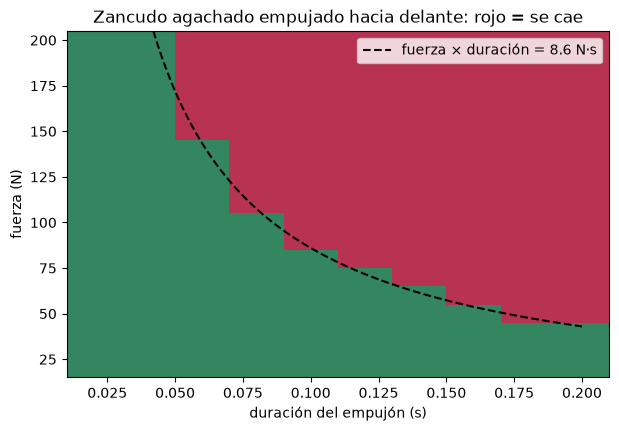

In [30]:
impulso = fuerzas * duraciones                                  # (190,) en N·s
print(f"el mayor impulso que aguanta: {impulso[~cae].max():.2f} N·s")
print(f"el menor impulso que tumba:   {impulso[cae].min():.2f} N·s")

fig, eje = plt.subplots(figsize=(7, 4.5))
eje.pcolormesh(D, F, mapa, cmap="RdYlGn_r", shading="nearest", alpha=0.8)
umbral = (impulso[~cae].max() + impulso[cae].min()) / 2
d_fina = np.linspace(D[0], D[-1], 200)
eje.plot(d_fina, umbral / d_fina, "k--", label=f"fuerza × duración = {umbral:.1f} N·s")
eje.set(xlabel="duración del empujón (s)", ylabel="fuerza (N)", ylim=(F[0] - 5, F[-1] + 5),
        title="Zancudo agachado empujado hacia delante: rojo = se cae")
eje.legend(loc="upper right")
plt.show()

**La hipótesis se cumple casi al milímetro.** El mayor impulso que aguanta es 8,4 N·s y el menor que tumba, 8,8 N·s: no hay solapamiento. La frontera entre verde y rojo es la curva fuerza = umbral / duración (una hipérbola): empujar el doble de fuerte la mitad de tiempo da lo mismo. Para un robot quieto que no reacciona, un empujón corto es, en la práctica, **una velocidad que se le da de golpe** (impulso = masa × cambio de velocidad), y lo que decide si cae es esa velocidad.

Un mapa así, con un bucle de 190 experimentos sueltos y listas, serían cuarenta líneas de cuentas a mano. Con formas: una máscara, un `any`, un `reshape` y un producto.

### Tus retos

**Reto 1.** Con la máscara `cae` y la tabla de impulsos, ¿cuál es la casilla **más débil** que tumba a Zancudo (la de menor fuerza)? Da su fuerza, su duración y cuándo se cayó. (Pista: `np.flatnonzero`, sección 3, o una máscara y `argmin`.)

<details>
<summary>▶ Solución</summary>

```python
indices = np.flatnonzero(cae)                       # números de los experimentos que caen
k = indices[np.argmin(fuerzas[indices])]           # de esos, el de menor fuerza
print(f"{fuerzas[k]:.0f} N durante {duraciones[k]:.2f} s (impulso {impulso[k]:.1f} N·s): cae a los {instante[k]:.2f} s")
```

Sale 50 N durante 0,18 s (9,0 N·s), y cae a los 1,92 s: el más lento de todos, porque es de los que menos pasan del umbral. (Con 50 N y 0,2 s también cae; `argmin` devuelve el **primero** de los empatados.) Fíjate en el patrón `indices[np.argmin(valores[indices])]`: `argmin` da una posición **dentro** del subconjunto, y hay que traducirla de vuelta a la numeración original.
</details>

**Reto 2.** ¿Cae **antes** un Zancudo con más impulso? Calcula la correlación (`np.corrcoef`) entre el impulso y el instante de caída, solo entre los que caen.

<details>
<summary>▶ Solución</summary>

```python
print(np.corrcoef(impulso[cae], instante[cae])[0, 1])
```

Unos **−0,87**: una relación negativa fuerte. Cuanto más impulso, más deprisa vuelca (de 1,92 s, rozando el umbral, a 0,84 s con los empujones más fuertes). Cerca del umbral, Zancudo se queda un buen rato "dudando" sobre la punta del pie antes de caer: la mitad divergente del péndulo invertido (NB39), que al principio crece muy despacio.
</details>

**Reto 3.** ★ Repite el lote empujando **hacia atrás** (`fuerzas = -FF.ravel()`; crea un lote nuevo de datos). ¿El umbral de impulso es el mismo? ¿Por qué?

<details>
<summary>▶ Solución</summary>

Crea el lote otra vez (los datos viejos ya están caídos), cambia el signo de las fuerzas y vuelve a ejecutar las celdas de los pasos 3 y 4 (con `impulso = np.abs(fuerzas) * duraciones`).

Hacia atrás caen más (126 de 190, frente a 102) y el umbral baja a unos **6 N·s** (frente a 8,4-8,8). El pie de Zancudo sobresale **14 cm por delante** del tobillo y solo **6 cm por detrás** (NB42): tiene menos suelo para frenar una caída hacia atrás, igual que tú, que aguantas mejor un empujón por la espalda (te inclinas sobre los dedos) que uno en el pecho (solo tienes el talón). Aquí el umbral ya no es tan limpio (con 6,0 N·s, unos caen y otros no): cerca del talón, la forma exacta del empujón empieza a importar.
</details>

### Qué has aprendido de MuJoCo hoy

- A simular **un lote**: un solo `MjModel` compartido y **N** `MjData` independientes (cada uno con su memoria).
- `datos.xfrc_applied` calculado para todo el lote con `np.where` y broadcasting; el registro en un array reservado `(N, T, k)`.
- Qué se vectoriza y qué no: el control y el análisis sí; `mj_step` no (cada paso depende del anterior): para eso existe `rollout` (NB49).
- Física medida con un barrido: lo que tumba a un robot quieto es el **impulso** (fuerza × duración), con un umbral distinto hacia delante y hacia atrás por la forma del pie.

En la práctica del **P7** usarás el álgebra lineal de la lección sobre el propio MuJoCo: el **jacobiano** de un pie con `mj_jac`, la **pseudoinversa** para llevar el pie a un punto y la **matriz de masas** de Zancudo, comprobando con valores propios que es simétrica y definida positiva.


## 13 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Queda una última lección del puente, el **P7**: el **álgebra lineal** que vas a necesitar desde el NB45 (inversa, determinante, rango, valores propios, SVD, número de condición, pseudoinversa, producto vectorial), explicada desde cero con dibujos y comprobada con `np.linalg`.
